In [1]:
import pandas as pd
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu 
import numpy as np 

In [2]:
import constants as c
import helpers as h 
h.latex(True)

2026-02-06 13:20:03 - analysis-helpers - INFO - Enabling LaTeX for matplotlib.


In [3]:
d = pd.read_csv(c.CURRENT_NO_COVARIATES_DF)
d = h.add_covariate_cols(d)
d = h.add_estimate_cols(d)

EST_TO_USE = c.ESTIMATE_TO_USE 


2026-02-06 13:20:03 - analysis-helpers - INFO - Found 192 tracts with at least one FloodNet sensor.
2026-02-06 13:20:03 - analysis-helpers - INFO - Found 2171 311 requests.
2026-02-06 13:20:03 - analysis-helpers - INFO - Found 878 tracts with at least one 311 report.
2026-02-06 13:20:03 - analysis-helpers - INFO - Found 1001 tracts with no DEP flooding.
2026-02-06 13:20:03 - analysis-helpers - INFO - Found 176 tracts with confirmed flooding.
2026-02-06 13:20:03 - analysis-helpers - INFO - Found 243 tracts with above threshold (0.005794175475956851) flooding.
2026-02-06 13:20:03 - analysis-helpers - INFO - Found 287 tracts with confirmed or above threshold flooding.


In [4]:
d = d[['p_y', EST_TO_USE, 'any_311_report', 'any_sensors',
       'ft_elevation_min', 'ft_elevation_mean', 'ft_elevation_max', 'dep_moderate_1_frac', 'dep_moderate_2_frac', 'catch_basin_density',  'has_clogged_cb_complaint','cb_avg_resolution_time']]



In [5]:
d

,p_y,confirmed_or_above_thres,any_311_report,any_sensors,ft_elevation_min,ft_elevation_mean,ft_elevation_max,dep_moderate_1_frac,dep_moderate_2_frac,catch_basin_density,has_clogged_cb_complaint,cb_avg_resolution_time
0,0.059597,True,False,False,0.0,8.153329,19.0,0.000000,0.000000,0.000000,0,0.000000
1,0.001020,False,True,False,24.0,34.847163,43.0,0.000000,0.000000,0.000013,0,0.000000
2,0.000892,False,False,False,13.0,27.553037,42.0,0.003108,0.006067,0.000036,0,0.000000
3,0.000400,False,False,False,8.0,36.394639,45.0,0.000000,0.000000,0.000039,1,2.666667
4,0.000590,False,True,False,9.0,17.288704,28.0,0.008606,0.009712,0.000020,1,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
2320,0.000609,False,True,False,0.0,13.570671,60.0,0.000912,0.001145,0.000018,1,1.000000
2321,0.001864,False,True,False,0.0,28.105886,67.0,0.058560,0.091331,0.000022,1,0.000000
2322,0.002090,False,True,False,6.0,38.929474,89.0,0.041022,0.047242,0.000016,1,1.000000
2323,0.000854,False,True,False,42.0,78.685942,93.0,0.000000,0.000000,0.000025,1,0.000000


In [6]:
row_mapping = {
    'any_311_report': r'Any 311 Report in tract?',
    'any_sensors': r'Any FloodNet sensors in tract?',
    'ft_elevation_min': r'Minimum elevation in tract [ft]',
    'ft_elevation_mean': r'Mean elevation in tract [ft]',
    'ft_elevation_max': r'Maximum elevation in tract [ft]',
    'dep_moderate_1_frac': r'Frac. DEP Shallow Flooding [$\mathrm{ft}^2$]',
    'dep_moderate_2_frac': r'Frac. DEP Deep Flooding [$\mathrm{ft}^2$]',
    'catch_basin_density': r'Catch Basin Density [basins/$\mathrm{km}^2$] $\times 10^{2}$',
    'cb_avg_resolution_time': r'Avg. CB Resolution Time [days]',
    'has_clogged_cb_complaint': r'Any Clogged CB Complaint (Jun--Sep 2023)?',
}



In [7]:
# Verify all columns are mapped
print("Keys in row_mapping:", list(row_mapping.keys()))

Keys in row_mapping: ['any_311_report', 'any_sensors', 'ft_elevation_min', 'ft_elevation_mean', 'ft_elevation_max', 'dep_moderate_1_frac', 'dep_moderate_2_frac', 'catch_basin_density', 'cb_avg_resolution_time', 'has_clogged_cb_complaint']


any_311_report 1.3470817635005619
p-value any_311_report 3.937849641626416e-05
any_sensors 1.9882926829268293
p-value any_sensors 2.782023681650501e-05
ft_elevation_min 0.5371002137853512
p-value ft_elevation_min 3.425879375402349e-24
ft_elevation_mean 0.7127069024840489
p-value ft_elevation_mean 3.823955491159378e-17
ft_elevation_max 0.8898353626640327
p-value ft_elevation_max 7.938319492180675e-06
dep_moderate_1_frac 1.425588452087977
p-value dep_moderate_1_frac 2.6828500933284234e-05
dep_moderate_2_frac 1.3515284168815431
p-value dep_moderate_2_frac 2.965885007347222e-05
catch_basin_density 0.7929576179734144
p-value catch_basin_density 2.7885888985569694e-13
has_clogged_cb_complaint 1.0303964328354573
p-value has_clogged_cb_complaint 0.5854108702731358
cb_avg_resolution_time 0.8887907133283224
p-value cb_avg_resolution_time 0.29933432109297375


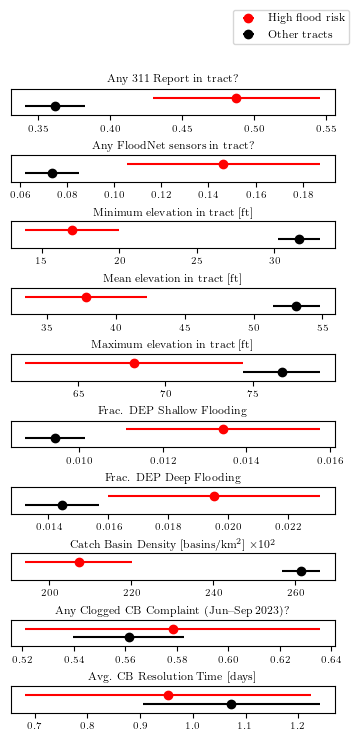

In [8]:
# Define row_mapping inline to avoid stale kernel state issues
row_mapping = {
    'any_311_report': r'Any 311 Report in tract?',
    'any_sensors': r'Any FloodNet sensors in tract?',
    'ft_elevation_min': r'Minimum elevation in tract [ft]',
    'ft_elevation_mean': r'Mean elevation in tract [ft]',
    'ft_elevation_max': r'Maximum elevation in tract [ft]',
    'dep_moderate_1_frac': r'Frac. DEP Shallow Flooding',
    'dep_moderate_2_frac': r'Frac. DEP Deep Flooding',
    'catch_basin_density': r'Catch Basin Density [basins/$\mathrm{km}^2$] $\times 10^{2}$',
    'cb_avg_resolution_time': r'Avg. CB Resolution Time [days]',
    'has_clogged_cb_complaint': r'Any Clogged CB Complaint (Jun--Sep 2023)?',
}

d['catch_basin_density'] = d['catch_basin_density'] * 10763910.417
d['high_flood_risk'] = d[EST_TO_USE]
# drop EST_TO_USE 
d = d.drop(EST_TO_USE, axis=1)
plot_num = 0
fig = plt.figure(figsize=[4, 8])

legend_handles = []
legend_labels = []

for k in d.columns:
    if 'p_y' not in k and 'high_flood_risk' not in k:
        plot_num += 1
        ax = plt.subplot(12, 1, plot_num)
        means_by_bin = d.groupby('high_flood_risk')[k].mean()
        stds_by_bin = d.groupby('high_flood_risk')[k].std()
        bin_sizes = d.groupby('high_flood_risk').size()
        assert list(means_by_bin.index) == [0, 1]
        
        # print the ratio of the means for each feature
        print(k, means_by_bin.iloc[1] / means_by_bin.iloc[0])
        
        if plot_num == 1:
            high_risk = plt.errorbar(means_by_bin.iloc[1],
                            0.75, 
                            xerr=1.96 * stds_by_bin.iloc[1] / (bin_sizes.iloc[1]**0.5), 
                            color='red', 
                            fmt='o', 
                            label='High flood risk')
            other_tracts = plt.errorbar(means_by_bin.iloc[0], 
                            0.25, 
                            xerr=1.96 * stds_by_bin.iloc[0] / (bin_sizes.iloc[0]**0.5), 
                            color='black', 
                            fmt='o', 
                            label='Other tracts')
            legend_handles = [high_risk, other_tracts]
            legend_labels = ['High flood risk', 'Other tracts']
        else:
            plt.errorbar(means_by_bin.iloc[1],
                        0.75, 
                        xerr=1.96 * stds_by_bin.iloc[1] / (bin_sizes.iloc[1]**0.5), 
                        color='red', 
                        fmt='o')
            plt.errorbar(means_by_bin.iloc[0], 
                        0.25, 
                        xerr=1.96 * stds_by_bin.iloc[0] / (bin_sizes.iloc[0]**0.5), 
                        color='black', 
                        fmt='o')

        p_val = mannwhitneyu(d.loc[d['high_flood_risk'] == 1, k], 
                             d.loc[d['high_flood_risk'] == 0, k])[1]
        plt.ylim([-0.25, 1.25])

        
       
        
        plt.title(row_mapping[k], fontsize=8, pad=4)
        
        # Add p-value with stars to the right side
        #stars = ''
        #if p_val < 0.001:
        #    stars = '***'
       # elif p_val < 0.01:
       #     stars = '**'
       # elif p_val < 0.05:
       #     stars = '*'

        print("p-value", k, p_val)
            
        #ax.text(1.02, 1.2, f'{stars}', 
        #        transform=ax.transAxes,
        #        fontsize=8,
       #         horizontalalignment='right',
       #         verticalalignment='center')
        
        plt.yticks([])
        # set x ticks font size 
        plt.xticks(fontsize=7)

plt.tight_layout()

fig.legend(legend_handles, legend_labels, 
          loc='upper right', 
          bbox_to_anchor=(0.9, 1.07), fontsize=8)

plt.subplots_adjust(right=0.85, hspace=1.5)

plt.savefig(f'{c.PAPER_PATH}/figures/external_corrs_vs_risk.pdf', dpi=200, pad_inches=0.025)

In [9]:
# what is the pearson between high flood risk and each of the features?
for k in d.columns:
    if 'p_y' not in k and 'high_flood_risk' not in k:
        print(k, pearsonr(d['high_flood_risk'], d[k]))

any_311_report PearsonRResult(statistic=np.float64(0.08527966629261692), pvalue=np.float64(3.8329134224401334e-05))
any_sensors PearsonRResult(statistic=np.float64(0.08692999516690993), pvalue=np.float64(2.7010902310044133e-05))
ft_elevation_min PearsonRResult(statistic=np.float64(-0.15564284260131694), pvalue=np.float64(4.4600081706468794e-14))
ft_elevation_mean PearsonRResult(statistic=np.float64(-0.1271698538752842), pvalue=np.float64(7.573911986415608e-10))
ft_elevation_max PearsonRResult(statistic=np.float64(-0.05458189896429905), pvalue=np.float64(0.008478624699264992))
dep_moderate_1_frac PearsonRResult(statistic=np.float64(0.0775153226105675), pvalue=np.float64(0.00018309008845389675))
dep_moderate_2_frac PearsonRResult(statistic=np.float64(0.05828862358244184), pvalue=np.float64(0.00493180363648413))
catch_basin_density PearsonRResult(statistic=np.float64(-0.16381453797756204), pvalue=np.float64(1.8900814960574687e-15))
has_clogged_cb_complaint PearsonRResult(statistic=np.floa

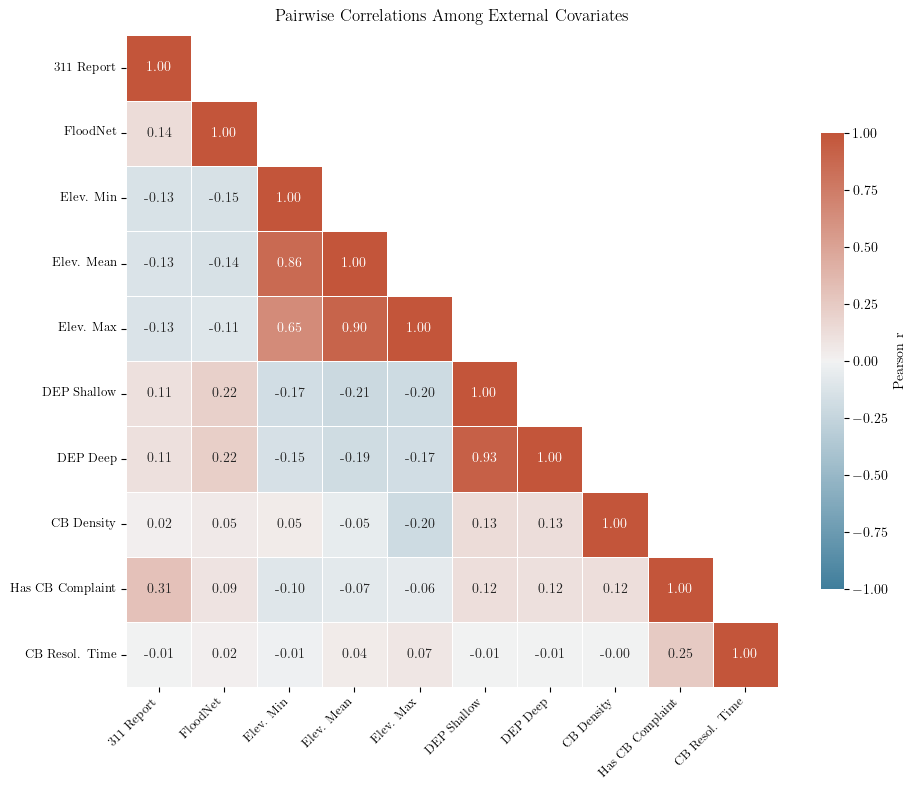

In [10]:
# Covariate correlation heatmap
covariate_cols = [c for c in d.columns if c not in ['p_y', 'high_flood_risk']]

# Compute correlation matrix
corr_matrix = d[covariate_cols].corr(method='pearson')

# Create shorter labels for the heatmap
short_labels = {
    'any_311_report': '311 Report',
    'any_sensors': 'FloodNet',
    'ft_elevation_min': 'Elev. Min',
    'ft_elevation_mean': 'Elev. Mean',
    'ft_elevation_max': 'Elev. Max',
    'dep_moderate_1_frac': 'DEP Shallow',
    'dep_moderate_2_frac': 'DEP Deep',
    'catch_basin_density': 'CB Density',
    'cb_avg_resolution_time': 'CB Resol. Time',
    'has_clogged_cb_complaint': 'Has CB Complaint'
}

# Rename for display
corr_display = corr_matrix.rename(index=short_labels, columns=short_labels)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_display, dtype=bool), k=1)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_display, 
            mask=mask,
            cmap=cmap, 
            center=0,
            vmin=-1, vmax=1,
            annot=True, 
            fmt='.2f',
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.7, 'label': 'Pearson r'},
            ax=ax)

ax.set_title('Pairwise Correlations Among External Covariates', fontsize=12, pad=10)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

plt.savefig(f'{c.PAPER_PATH}/figures/covariate_correlation_heatmap.pdf', dpi=200, bbox_inches='tight')


In [11]:
# Print correlation matrix in text format
print("Pairwise Pearson Correlations Among External Covariates")
print("=" * 60)
print()

# Show full matrix with short labels
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(corr_display.round(2).to_string())
print()

# Also show strongest correlations (|r| > 0.3)
print("\nStrongest correlations (|r| > 0.3):")
print("-" * 40)
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.3:
            col1 = short_labels[corr_matrix.columns[i]]
            col2 = short_labels[corr_matrix.columns[j]]
            print(f"{col1} <-> {col2}: r = {r:.3f}")


Pairwise Pearson Correlations Among External Covariates

                  311 Report  FloodNet  Elev. Min  Elev. Mean  Elev. Max  DEP Shallow  DEP Deep  CB Density  Has CB Complaint  CB Resol. Time
311 Report              1.00      0.14      -0.13       -0.13      -0.13         0.11      0.11        0.02              0.31           -0.01
FloodNet                0.14      1.00      -0.15       -0.14      -0.11         0.22      0.22        0.05              0.09            0.02
Elev. Min              -0.13     -0.15       1.00        0.86       0.65        -0.17     -0.15        0.05             -0.10           -0.01
Elev. Mean             -0.13     -0.14       0.86        1.00       0.90        -0.21     -0.19       -0.05             -0.07            0.04
Elev. Max              -0.13     -0.11       0.65        0.90       1.00        -0.20     -0.17       -0.20             -0.06            0.07
DEP Shallow             0.11      0.22      -0.17       -0.21      -0.20         1.00      

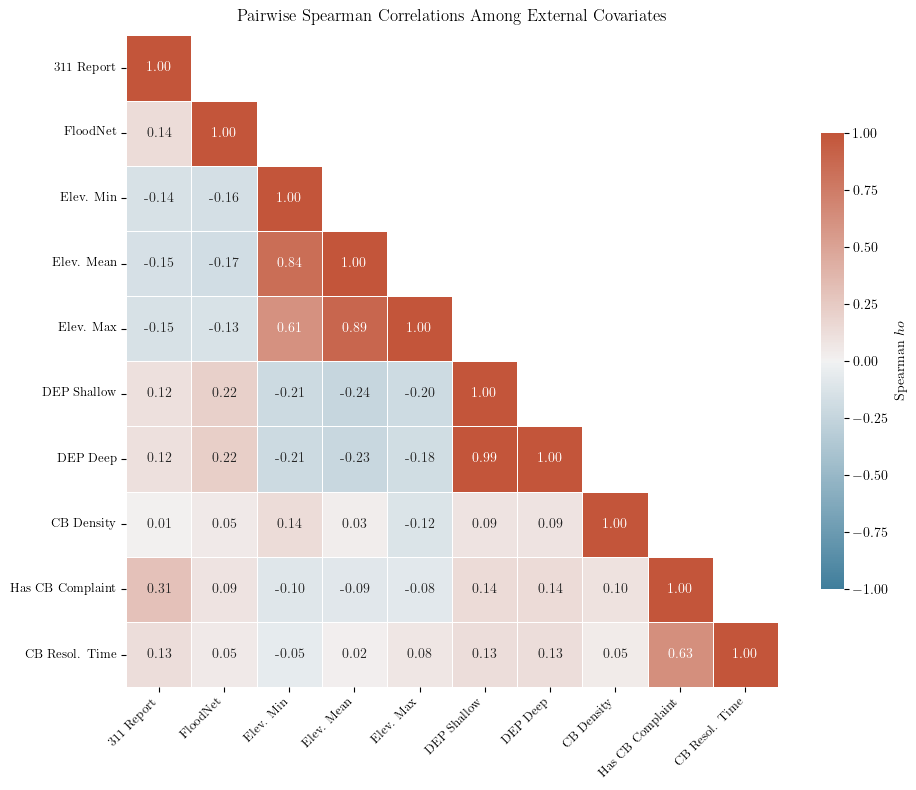

In [12]:
# Spearman correlation heatmap
corr_matrix_spearman = d[covariate_cols].corr(method='spearman')

# Rename for display
corr_display_spearman = corr_matrix_spearman.rename(index=short_labels, columns=short_labels)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_display_spearman, dtype=bool), k=1)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_display_spearman, 
            mask=mask,
            cmap=cmap, 
            center=0,
            vmin=-1, vmax=1,
            annot=True, 
            fmt='.2f',
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.7, 'label': 'Spearman $\rho$'},
            ax=ax)

ax.set_title('Pairwise Spearman Correlations Among External Covariates', fontsize=12, pad=10)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

plt.savefig(f'{c.PAPER_PATH}/figures/covariate_correlation_heatmap_spearman.pdf', dpi=200, bbox_inches='tight')


In [13]:
# Print Spearman correlation matrix in text format
print("Pairwise Spearman Correlations Among External Covariates")
print("=" * 60)
print()

# Show full matrix with short labels
print(corr_display_spearman.round(2).to_string())
print()

# Also show strongest correlations (|ρ| > 0.3)
print("\nStrongest correlations (|ρ| > 0.3):")
print("-" * 40)
for i in range(len(corr_matrix_spearman.columns)):
    for j in range(i+1, len(corr_matrix_spearman.columns)):
        rho = corr_matrix_spearman.iloc[i, j]
        if abs(rho) > 0.3:
            col1 = short_labels[corr_matrix_spearman.columns[i]]
            col2 = short_labels[corr_matrix_spearman.columns[j]]
            print(f"{col1} <-> {col2}: ρ = {rho:.3f}")


Pairwise Spearman Correlations Among External Covariates

                  311 Report  FloodNet  Elev. Min  Elev. Mean  Elev. Max  DEP Shallow  DEP Deep  CB Density  Has CB Complaint  CB Resol. Time
311 Report              1.00      0.14      -0.14       -0.15      -0.15         0.12      0.12        0.01              0.31            0.13
FloodNet                0.14      1.00      -0.16       -0.17      -0.13         0.22      0.22        0.05              0.09            0.05
Elev. Min              -0.14     -0.16       1.00        0.84       0.61        -0.21     -0.21        0.14             -0.10           -0.05
Elev. Mean             -0.15     -0.17       0.84        1.00       0.89        -0.24     -0.23        0.03             -0.09            0.02
Elev. Max              -0.15     -0.13       0.61        0.89       1.00        -0.20     -0.18       -0.12             -0.08            0.08
DEP Shallow             0.12      0.22      -0.21       -0.24      -0.20         1.00     

In [14]:
d['high_flood_risk'].value_counts()

high_flood_risk
False    2038
True      287
Name: count, dtype: int64

In [15]:
# T-tests for each feature: high flood risk vs other tracts
from scipy.stats import ttest_ind

print("Independent t-tests: High Flood Risk vs Other Tracts")
print("=" * 70)
print()

ttest_results = []

for k in d.columns:
    if 'p_y' not in k and 'high_flood_risk' not in k:
        high_risk_vals = d.loc[d['high_flood_risk'] == 1, k].dropna()
        other_vals = d.loc[d['high_flood_risk'] == 0, k].dropna()
        
        t_stat, t_pval = ttest_ind(high_risk_vals, other_vals)
        
        # Also run Mann-Whitney for comparison
        mw_stat, mw_pval = mannwhitneyu(high_risk_vals, other_vals)
        
        # Compute means and effect size (Cohen's d)
        mean_high = high_risk_vals.mean()
        mean_other = other_vals.mean()
        pooled_std = np.sqrt(((len(high_risk_vals)-1)*high_risk_vals.std()**2 + 
                              (len(other_vals)-1)*other_vals.std()**2) / 
                             (len(high_risk_vals) + len(other_vals) - 2))
        cohens_d = (mean_high - mean_other) / pooled_std if pooled_std > 0 else np.nan

        pearson_pval = pearsonr(d['high_flood_risk'], d[k])[1]

     
        
        # Print significance stars
        stars = ''
        if t_pval < 0.001:
            stars = '***'
        elif t_pval < 0.01:
            stars = '**'
        elif t_pval < 0.05:
            stars = '*'

               
        ttest_results.append({
            'Feature': row_mapping.get(k, k),
            'Mean (High Risk)': mean_high,
            'Mean (Low Risk)': mean_other,
            't-statistic': t_stat,
            't-test p-value': t_pval,
            'Mann-Whitney p-value': mw_pval,
            'Pearson p-value': pearson_pval,
            't-test Significance': stars
        })
        
        print(f"{row_mapping.get(k, k)}")
        print(f"  t-statistic: {t_stat:.3f}, p-value: {t_pval:.4g} {stars}")
        print(f"  Mann-Whitney p-value: {mw_pval:.4g}")
        print(f"  Cohen's d: {cohens_d:.3f}")
        print()


Independent t-tests: High Flood Risk vs Other Tracts

Any 311 Report in tract?
  t-statistic: 4.125, p-value: 3.833e-05 ***
  Mann-Whitney p-value: 3.938e-05
  Cohen's d: 0.260

Any FloodNet sensors in tract?
  t-statistic: 4.206, p-value: 2.701e-05 ***
  Mann-Whitney p-value: 2.782e-05
  Cohen's d: 0.265

Minimum elevation in tract [ft]
  t-statistic: -7.594, p-value: 4.46e-14 ***
  Mann-Whitney p-value: 3.426e-24
  Cohen's d: -0.479

Mean elevation in tract [ft]
  t-statistic: -6.179, p-value: 7.574e-10 ***
  Mann-Whitney p-value: 3.824e-17
  Cohen's d: -0.390

Maximum elevation in tract [ft]
  t-statistic: -2.635, p-value: 0.008479 **
  Mann-Whitney p-value: 7.938e-06
  Cohen's d: -0.166

Frac. DEP Shallow Flooding
  t-statistic: 3.747, p-value: 0.0001831 ***
  Mann-Whitney p-value: 2.683e-05
  Cohen's d: 0.236

Frac. DEP Deep Flooding
  t-statistic: 2.814, p-value: 0.004932 **
  Mann-Whitney p-value: 2.966e-05
  Cohen's d: 0.177

Catch Basin Density [basins/$\mathrm{km}^2$] $\times

In [16]:

# Create summary DataFrame
ttest_df = pd.DataFrame(ttest_results)
print("\nSummary Table:")
print(ttest_df.to_string(index=False))


Summary Table:
                                                     Feature  Mean (High Risk)  Mean (Low Risk)  t-statistic  t-test p-value  Mann-Whitney p-value  Pearson p-value t-test Significance
                                    Any 311 Report in tract?          0.487805         0.362120     4.125296    3.832913e-05          3.937850e-05     3.832913e-05                 ***
                              Any FloodNet sensors in tract?          0.146341         0.073602     4.205730    2.701090e-05          2.782024e-05     2.701090e-05                 ***
                             Minimum elevation in tract [ft]         16.958188        31.573602    -7.594144    4.460008e-14          3.425879e-24     4.460008e-14                 ***
                                Mean elevation in tract [ft]         37.847476        53.103844    -6.179442    7.573912e-10          3.823955e-17     7.573912e-10                 ***
                             Maximum elevation in tract [ft]    